In [238]:
library("DESeq2")
library("WGCNA")
library("pheatmap")
library(dynamicTreeCut)

In [239]:
# Load the counts and the metadata
rna_counts <- read.table("rna_counts.txt", header = TRUE, row.names = 1, sep="\t")
mirna_counts <- read.table("mirna_counts.txt", header = TRUE, row.names = 1, sep="\t")
metadata <- read.table("all_metadata.csv", header = TRUE, row.names = 1, sep=",")


In [240]:
head(rna_counts,2 )

,SRR5580910,SRR5580911,SRR5580912,SRR5580913,SRR5580914,SRR5580915,SRR5580916,SRR5580917,SRR5580920,SRR5580921,⋯,SRR5581285,SRR5581286,SRR5581287,SRR5581289,SRR5581300,SRR5581301,SRR5581322,SRR5581323,SRR5581324,SRR5581325
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
OR4F5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F29,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [241]:
head(mirna_counts,2)

,SRR5580918,SRR5580919,SRR5580922,SRR5580923,SRR5580924,SRR5580925,SRR5580928,SRR5580929,SRR5580930,SRR5580931,⋯,SRR5581312,SRR5581313,SRR5581314,SRR5581315,SRR5581316,SRR5581317,SRR5581318,SRR5581319,SRR5581320,SRR5581321
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
hsa-miR-6859-5p,1,3,1,0,0,2,1,0,0,1,⋯,1,3,1,0,3,0,2,3,3,0
hsa-miR-6859-3p,0,0,0,0,0,0,0,0,0,1,⋯,0,1,0,0,0,2,0,2,0,0


In [242]:
head(metadata, 2)

,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,⋯,PHENOTYPE,Platform,RACE,ReleaseDate,create_date,version,Sample.Name,sex,SRA.Study,tissue
,<int>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
SRR5580910,53,RNA-Seq,260,8678680221,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140646,Human,3306606952,CHANG GUNG UNIVERSITY,⋯,adjacent normal,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:10:00Z,1,CRC_078-N,male,SRP107326,rectum
SRR5580911,53,RNA-Seq,263,8186874340,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140647,Human,3140298478,CHANG GUNG UNIVERSITY,⋯,neoplastic,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:11:00Z,1,CRC_078-T,male,SRP107326,rectum


In [243]:
colnames(metadata)

[1] "age"                  "Assay.Type"           "AvgSpotLen"          
 [4] "Bases"                "BIOMATERIAL_PROVIDER" "BioProject"          
 [7] "BioSample"            "BioSampleModel"       "Bytes"               
[10] "Center.Name"          "Consent"              "DATASTORE.filetype"  
[13] "DATASTORE.provider"   "DATASTORE.region"     "disease"             
[16] "disease_stage"        "ETHNICITY"            "Experiment"          
[19] "Instrument"           "isolate"              "Library.Name"        
[22] "LibraryLayout"        "LibrarySelection"     "LibrarySource"       
[25] "Organism"             "PHENOTYPE"            "Platform"            
[28] "RACE"                 "ReleaseDate"          "create_date"         
[31] "version"              "Sample.Name"          "sex"                 
[34] "SRA.Study"            "tissue"

In [244]:
# change column names of rna counts with the isolate from the metadata that has the same row name
colnames(rna_counts) <- metadata[colnames(rna_counts), "Sample.Name"]
# same for mirna counts
colnames(mirna_counts) <- metadata[colnames(mirna_counts), "Sample.Name"]

In [245]:
head(rna_counts, 2)

,CRC_078-N,CRC_078-T,CRC_076-N,CRC_076-T,CRC_089-N,CRC_089-T,CRC_079-N,CRC_079-T,CRC_101-N,CRC_101-T,⋯,CRC_161-N,CRC_160-T,CRC_160-N,CRC_104-N,CRC_013-T,CRC_104-T,CRC_186-N,CRC_186-T,CRC_182-N,CRC_182-T
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
OR4F5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F29,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [246]:
head(mirna_counts, 2)

,CRC_032-N,CRC_032-T,CRC_034-N,CRC_034-T,CRC_038-N,CRC_038-T,CRC_199-T,CRC_199-N,CRC_202-T,CRC_202-N,⋯,CRC_191-N,CRC_191-T,CRC_187-N,CRC_187-T,CRC_186-N,CRC_186-T,CRC_190-N,CRC_190-T,CRC_188-N,CRC_188-T
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
hsa-miR-6859-5p,1,3,1,0,0,2,1,0,0,1,⋯,1,3,1,0,3,0,2,3,3,0
hsa-miR-6859-3p,0,0,0,0,0,0,0,0,0,1,⋯,0,1,0,0,0,2,0,2,0,0


In [247]:
common_samples <- intersect(colnames(rna_counts), colnames(mirna_counts))
rna_subset <- rna_counts[, common_samples]
mirna_subset <- mirna_counts[, common_samples]

In [248]:
rownames(rna_subset) <- paste0("GENE_", rownames(rna_subset))
rownames(mirna_subset) <- paste0("MIRNA_", rownames(mirna_subset))
combined_counts <- rbind(rna_subset, mirna_subset)

In [249]:
head(combined_counts, 2)
tail(combined_counts, 2)

,CRC_078-N,CRC_078-T,CRC_076-N,CRC_076-T,CRC_089-N,CRC_089-T,CRC_079-N,CRC_079-T,CRC_101-N,CRC_101-T,⋯,CRC_161-N,CRC_160-T,CRC_160-N,CRC_104-N,CRC_013-T,CRC_104-T,CRC_186-N,CRC_186-T,CRC_182-N,CRC_182-T
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
GENE_OR4F5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GENE_OR4F29,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


,CRC_078-N,CRC_078-T,CRC_076-N,CRC_076-T,CRC_089-N,CRC_089-T,CRC_079-N,CRC_079-T,CRC_101-N,CRC_101-T,⋯,CRC_161-N,CRC_160-T,CRC_160-N,CRC_104-N,CRC_013-T,CRC_104-T,CRC_186-N,CRC_186-T,CRC_182-N,CRC_182-T
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
MIRNA_hsa-miR-9985,73,34,94,71,43,67,72,294,9,9,⋯,199,252,38,73,28,176,194,268,109,82
MIRNA_hsa-miR-12120,0,0,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,1,1


In [250]:
# remove from combined counts genes or miRNAs with value 0 for 95% or more of the samples
# Calculate the proportion of zero values in each row
zero_proportion <- rowMeans(combined_counts == 0)

# Keep only those rows where fewer than 95% of values are zero
combined_counts <- combined_counts[zero_proportion < 0.95, ]

In [251]:
# Make a new metadata for the combined counts
metadata <- metadata[metadata$Assay.Type == "RNA-Seq", ] # We have half the metadata now, avoid repeated sample names
rownames(metadata) <- metadata$Sample.Name

In [252]:
# make the differential expression with DESeq2
dds <- DESeqDataSetFromMatrix(countData = combined_counts,
                              colData = metadata,
                              design = ~ PHENOTYPE)
dds <- DESeq(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
 

In [253]:
res = results(dds, contrast = c("PHENOTYPE", "adjacent normal", "neoplastic"))
res = res[order(res$padj), ]

In [254]:
# show results for SALL2 only
sall2_res <- res[rownames(res) == "GENE_SALL2", ]
print(sall2_res)

log2 fold change (MLE): PHENOTYPE adjacent normal vs neoplastic 
Wald test p-value: PHENOTYPE adjacent normal vs neoplastic 
DataFrame with 1 row and 6 columns
            baseMean log2FoldChange     lfcSE      stat      pvalue        padj
           <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
GENE_SALL2   42.8706       0.554935  0.117846     4.709 2.48936e-06 4.18068e-06


In [255]:
# delete rows with NA in the padj column
res <- res[!is.na(res$padj), ]
dim(res)

[1] 20153     6

In [256]:
res_ordered <- res[order(res$padj), ]
df = res_ordered
df$Category <- "Not significant" # CRITERIOS PARA DEFINIR DEGs DESDE LA PRACTICA
df[which(df$log2FoldChange >= 0.5 & df$padj <= 0.001),]$Category <- "Up-regulated"
df[which(df$log2FoldChange <= -0.5 & df$padj <= 0.001),]$Category <- "Down-regulated"

In [257]:
table(df$Category)


 Down-regulated Not significant    Up-regulated 
           5418            9797            4938 

In [258]:
# get only those that are up or down regulated
df_sig <- df[df$Category != "Not significant", ]
dim(df_sig)

[1] 10356     7

In [259]:
# Create WGCNA network with significant genes
# Select only the significant genes
sig_genes <- rownames(df_sig)

In [260]:
# Obtain DESeq2 normalized counts for significant genes
norm_counts <- counts(dds, normalized = TRUE)[sig_genes, ]
datExpr0 <- t(norm_counts)

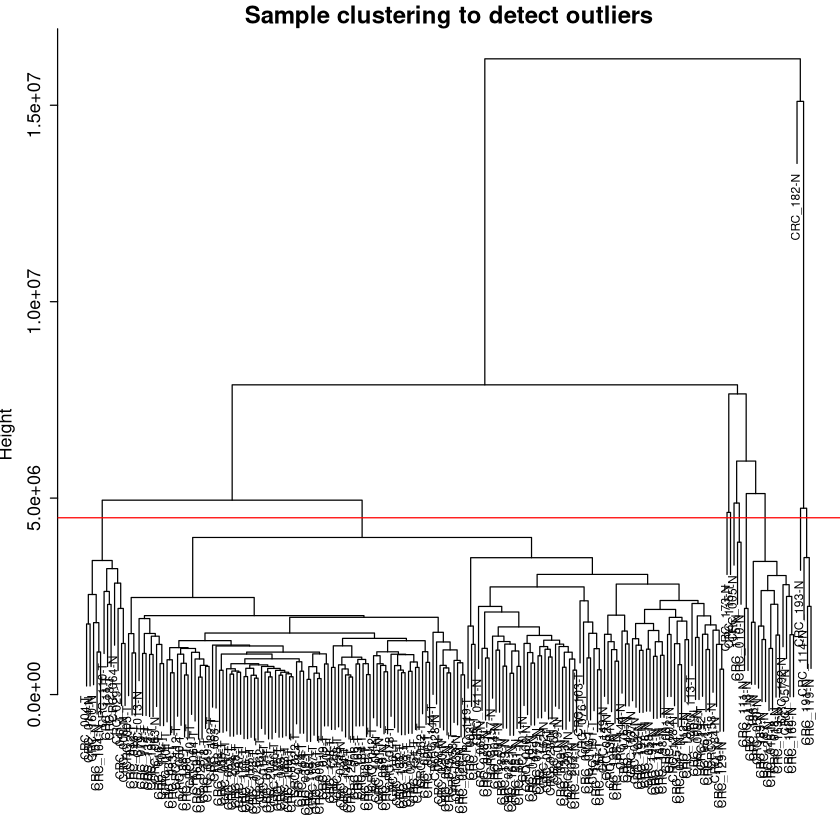

In [261]:
sampleTree <- hclust(dist(datExpr0), method = "average")
par(cex = 0.6)
par(mar = c(0,4,2,0))
plot(sampleTree, main = "Sample clustering to detect outliers", sub="", xlab="", cex.lab = 1.5, 
     cex.axis = 1.5, cex.main = 2)

#Plot a line showing the cut-off
abline(h = 4.5e+06, col = "red")

In [262]:
clust = cutreeStatic(sampleTree, cutHeight = 4.5e+06, minSize = 10)
#table(clust)
#clust

#Cluster 1 contains the samples we want to keep.
keepSamples = (clust==1)
datExpr0 = datExpr0[keepSamples, ]
nGenes = ncol(datExpr0)
nSamples = nrow(datExpr0)

In [263]:
datTraits = metadata[, c("PHENOTYPE", "age")]
# replace adajcent normal with 0 and neoplastic with 1
datTraits$PHENOTYPE <- ifelse(datTraits$PHENOTYPE == "adjacent normal", 0, 1)
datTraits <- datTraits[match(rownames(datExpr0), rownames(datTraits)), ]

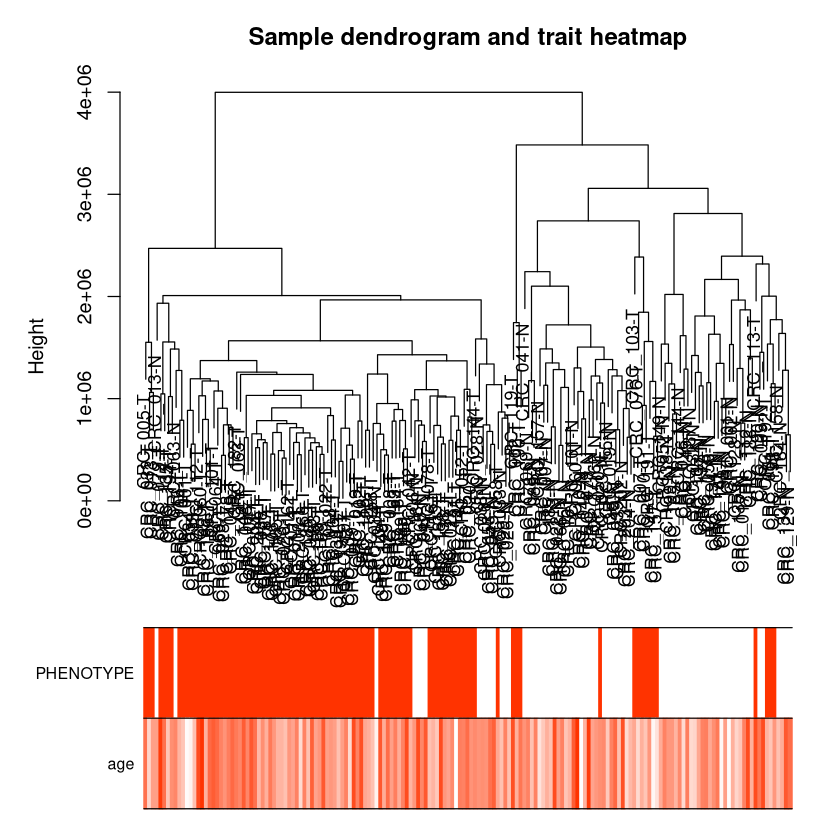

In [264]:
#Regrouping samples
sampleTree2 = hclust(dist(datExpr0), method = "average")
#Converting phenotypic characters in a color representation: white means low value, red means high value
#and gray missing value
traitColors = numbers2colors(datTraits, signed = FALSE)

#Plot a sample dendogram with the colors below
plotDendroAndColors(sampleTree2, traitColors,
                    groupLabels = names(datTraits), 
                    main = "Sample dendrogram and trait heatmap")

In [265]:
# create a WGCNA object
# Transpose the normalized counts matrix
gsg <- goodSamplesGenes(datExpr0, verbose = 3)
if (!gsg$allOK) {
  datExpr0 <- datExpr0[gsg$goodSamples, gsg$goodGenes]
}

 Flagging genes and samples with too many missing values...
  ..step 1


pickSoftThreshold: will use block size 4320.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 4320 of 10356
   ..working on genes 4321 through 8640 of 10356
   ..working on genes 8641 through 10356 of 10356
   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      1    0.406  0.696          0.765 3220.00  3370.000 5450.0
2      2    0.354 -0.490          0.626 1380.00  1340.000 3330.0
3      3    0.633 -0.870          0.813  694.00   595.000 2220.0
4      4    0.710 -1.070          0.886  388.00   283.000 1570.0
5      5    0.782 -1.180          0.940  233.00   142.000 1150.0
6      6    0.815 -1.260          0.962  148.00    74.300  870.0
7      7    0.849 -1.330          0.974   97.70    40.200  673.0
8      8    0.872 -1.370          0.982   67.00    23.100  531.0
9      9    0.890 -1.400          0.985   47.30    14.200  425.0
10    10    0.900 -1.420          0.981   34.30     8.890  345.0
11    11    0.915 -1.450      

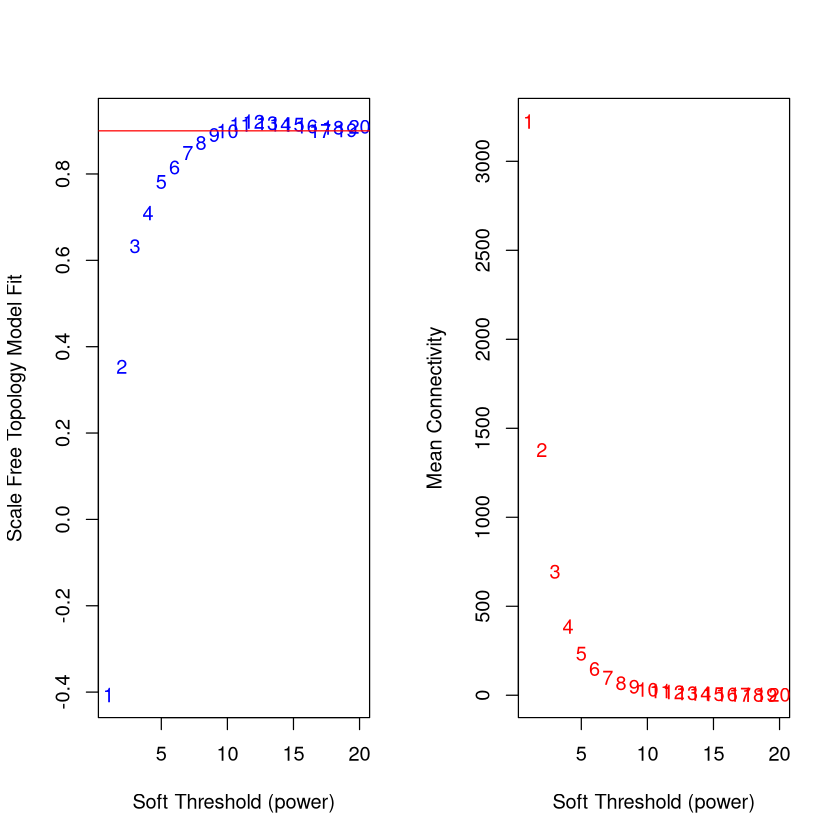

In [266]:
powers <- c(1:20)
sft <- pickSoftThreshold(datExpr0, powerVector = powers, verbose = 5)

# Plot scale independence and mean connectivity
par(mfrow = c(1,2))
plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit", type="n")
text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2], labels=powers, col="blue")
abline(h=0.9, col="red")

plot(sft$fitIndices[,1], sft$fitIndices[,5],
     xlab="Soft Threshold (power)", ylab="Mean Connectivity", type="n")
text(sft$fitIndices[,1], sft$fitIndices[,5], labels=powers, col="red")


In [270]:
net <- blockwiseModules(
  datExpr0,
  power = 12,                 # replace with chosen power
  TOMType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = FALSE,
  pamRespectsDendro = FALSE,
  verbose = 3,
  maxBlockSize = ncol(datExpr0)+1
)

 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will not use multithreading.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 1 genes from module 5 because their KME is too low.
     ..removing 2 genes from module 16 because their KME is too low.
     ..removing 1 genes from module 27 because their KME is too low.
 ..merging modules that are too close..
     mergeCloseModules: Merging modules whose distance is less than 0.25
       Calculating new MEs...


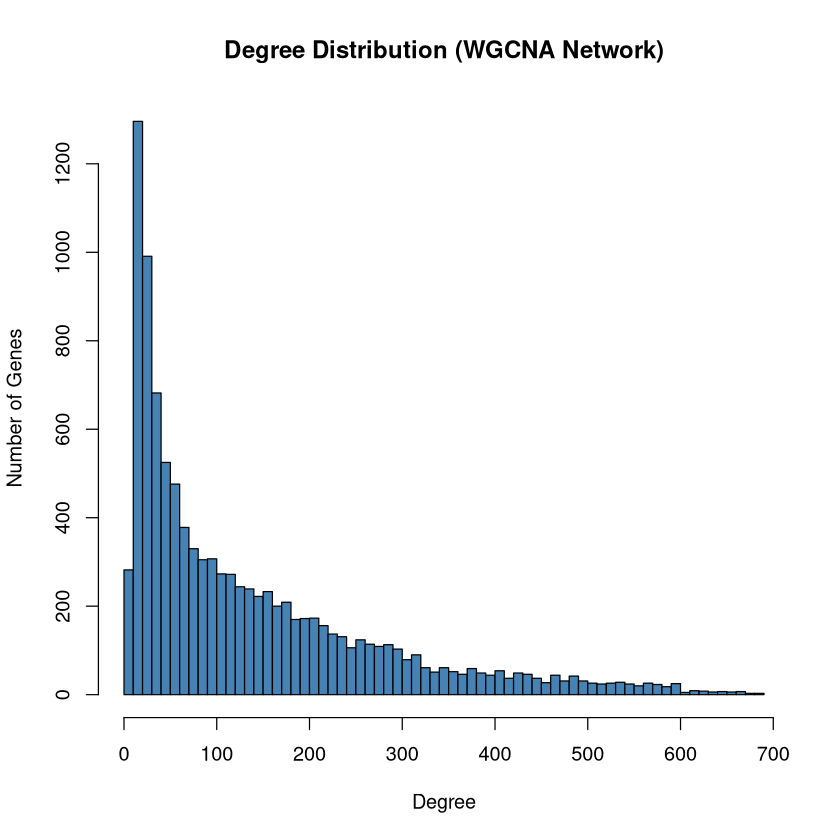

In [271]:
adjacency <- adjacency(datExpr0, power = 12, type = "signed")
degree <- rowSums(adjacency)

hist(degree,
     breaks = 50,
     col = "steelblue",
     main = "Degree Distribution (WGCNA Network)",
     xlab = "Degree",
     ylab = "Number of Genes")

In [272]:
# Subset to match your WGCNA data (after transposing)
sample_ids <- rownames(datExpr0)

# Extract trait (e.g., Tumor vs Normal)
trait_vector <- metadata[sample_ids, "PHENOTYPE"]
trait_vector2 <- metadata[sample_ids, "age"]

# One-hot encode it (if needed)
traitData <- data.frame(
  Tumor  = ifelse(trait_vector == "neoplastic", 1, 0),
  #Normal = ifelse(trait_vector == "adjacent normal", 1, 0),
  Age    = trait_vector2
)

rownames(traitData) <- sample_ids


In [273]:
MEs <- net$MEs
moduleTraitCor <- cor(MEs, traitData, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples = nrow(datExpr0))

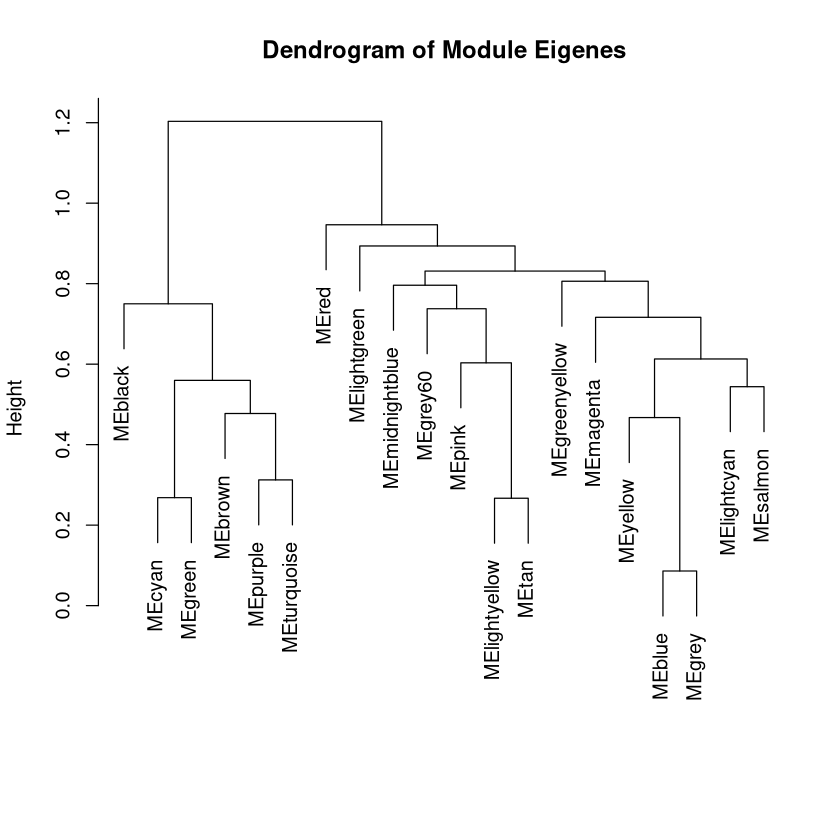

In [274]:
MEDiss <- 1 - cor(MEs)
METree <- hclust(as.dist(MEDiss), method = "average")
plot(METree, main="Dendrogram of Module Eigenes", xlab = "", sub = "")

In [275]:
# Converts the column names (e.g., ME1, ME2) to actual color names
moduleNames <- substring(names(MEs), 3)  # Removes the "ME" prefix


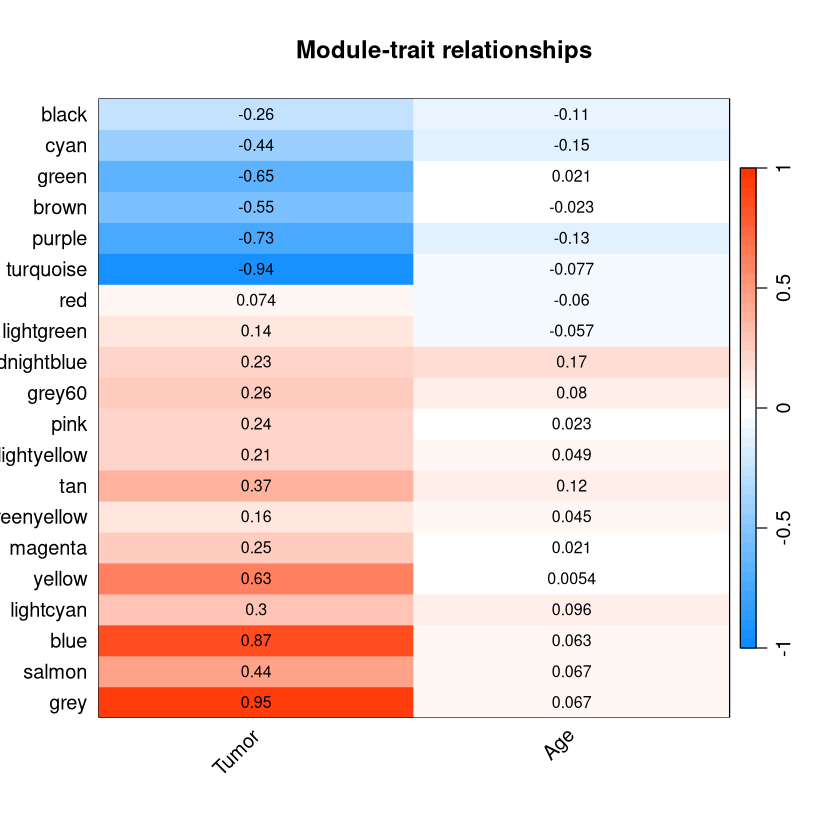

In [276]:
labeledHeatmap(Matrix = moduleTraitCor,
               xLabels = colnames(traitData),
               yLabels = moduleNames,
               ySymbols = moduleNames,
               colorLabels = TRUE,
               colors = blueWhiteRed(50),
               textMatrix = signif(moduleTraitCor, 2),
               setStdMargins = FALSE,
               cex.text = 0.8,
               zlim = c(-1,1),
               main = "Module-trait relationships")


In [277]:
# Convert numeric labels to colors if needed
moduleColors <- labels2colors(net$colors)

# Name the vector with gene names if not done yet
names(moduleColors) <- colnames(datExpr0)  # or your gene list

# Gene you want to find
gene_name <- "GENE_SALL2"

# Check which module the gene belongs to
gene_module <- moduleColors[gene_name]

if (is.na(gene_module)) {
  cat("Gene", gene_name, "not found in the dataset.\n")
} else {
  cat("Gene", gene_name, "belongs to module:", gene_module, "\n")
}


Gene GENE_SALL2 belongs to module: black 


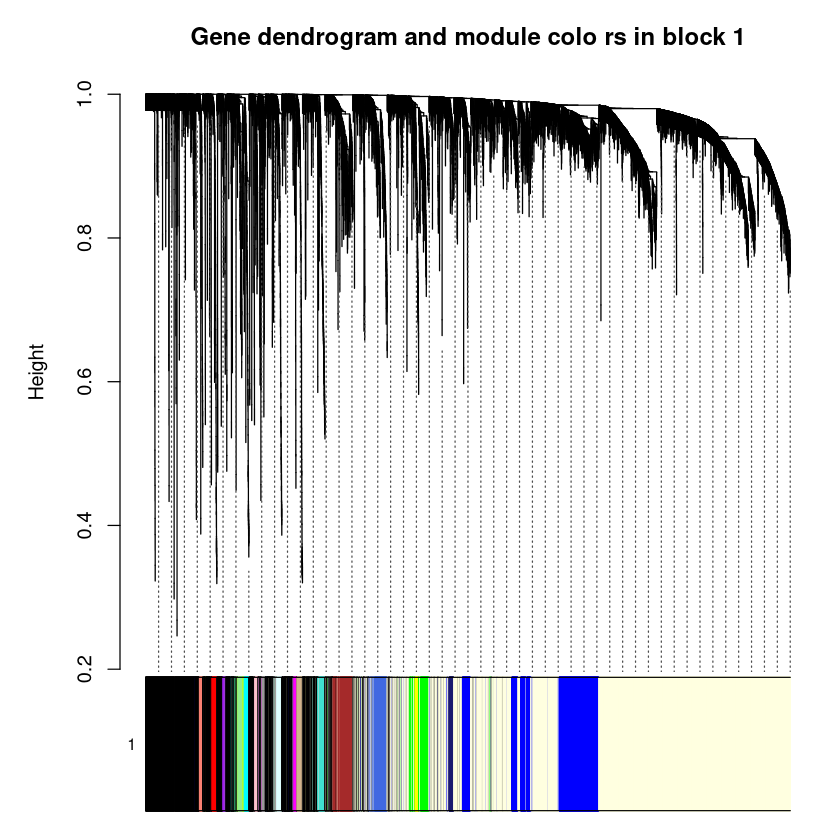

In [ ]:
plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]],
                    main = "Gene dendrogram and module colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)

In [279]:
# Get gene names (rownames of datExpr0) for module "blue"
genesInBlue <- colnames(datExpr0)[moduleColors == "blue"]

# View or save the list
length(genesInBlue)
write.csv(as.data.frame(genesInBlue), file = "genesInBlue.csv")

[1] 1094

In [280]:
# Get gene names (rownames of datExpr0) for module "blue"
genesInBlack <- colnames(datExpr0)[moduleColors == "black"]

# View or save the list
length(genesInBlack)
write.csv(as.data.frame(genesInBlack), file = "genesInBlack.csv")

[1] 2331

In [281]:
norm_counts = counts(dds, normalized=TRUE)
norm_counts_t = t(norm_counts)

In [282]:
# correlate GENE_SALL2 with evertything else
correlations <- cor(norm_counts_t[,"GENE_SALL2"], norm_counts_t, use = "pairwise.complete.obs")

In [283]:
correlations[, "GENE_ADD2"]

GENE_ADD2 
0.3053216

In [284]:
# subset the normalized counts, only keep those related to cancer and colon
colon_cancer_counts_t = norm_counts_t[metadata$PHENOTYPE == "neoplastic" & metadata$tissue == "colon", ]
correlations_cancer_colon <- cor(colon_cancer_counts_t[,"GENE_SALL2"], colon_cancer_counts_t, use = "pairwise.complete.obs")

In [285]:
correlations_cancer_colon[, "GENE_ADD2"]

GENE_ADD2 
0.8457625

In [286]:
write.csv(as.data.frame(t(correlations_cancer_colon)), file = "correlations_cancer_colon.csv")